## Data Division

**Os autores utilizaram as seguintes quantidades exatas para o experimento:**
- Treino: 6.245 fatias de imagens (exclusivamente de exames saudáveis/normais).
- Teste: 133 fatias de imagens (exclusivamente contendo tumores confirmados por biópsia).

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

In [23]:
load_dotenv()

merge_path = os.getenv('merge_path')
merge = pd.read_csv(merge_path)
merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         1163 non-null   str  
 1   StudyUID          1163 non-null   str  
 2   View              1163 non-null   str  
 3   Normal            1163 non-null   int64
 4   Actionable        1163 non-null   int64
 5   Benign            1163 non-null   int64
 6   Cancer            1163 non-null   int64
 7   descriptive_path  1163 non-null   str  
 8   classic_path      1163 non-null   str  
 9   ClassCode         1163 non-null   int64
dtypes: int64(5), str(5)
memory usage: 91.0 KB


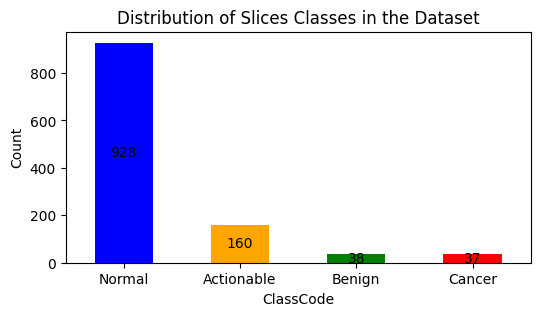

In [24]:
class_map = {'Normal': 0, 'Actionable': 1, 'Benign': 2, 'Cancer': 3}
class_counts = merge['ClassCode'].value_counts()

plt.figure(figsize=(6, 3))
ax = class_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title('Distribution of Slices Classes in the Dataset')
plt.bar_label(ax.containers[0], label_type="center")
plt.xlabel('ClassCode')
plt.ylabel('Count')
plt.xticks(ticks=range(len(class_map)), labels=class_map.keys(), rotation=0)
plt.show()

Os autores filtraram a base e trabalharam apenas com as classes normais e de câncer.

A divisão metodológica no experimento foi feita da seguinte forma:

Classe Normal (Saudável): Utilizada exclusivamente para o treinamento. Foram selecionadas 6.245 fatias de exames saudáveis para ensinar ao modelo o que é o padrão anatômico correto de uma mama.

Classe Câncer (Biopsied Cancer): Utilizada exclusivamente para o teste. Foram selecionadas 133 fatias contendo câncer já comprovado por biópsia para avaliar se o modelo conseguia localizar a anomalia.

As classes actionable (achados que exigem acompanhamento) e benign (tumores benignos) foram propositalmente descartadas pelos autores neste estudo. Isso geralmente é feito para criar um cenário de validação com um contraste mais claro, testando a capacidade da rede de aprender o tecido perfeitamente saudável e sinalizar lesões malignas confirmadas.

In [25]:
filtered_classes = merge[merge['ClassCode'].isin([0, 3])]
filtered_class_counts = filtered_classes['ClassCode'].value_counts()

filter_path = os.getenv('filter_classes')
filtered_classes.to_csv(filter_path, index=False)


print(filtered_class_counts)

ClassCode
0    928
3     37
Name: count, dtype: int64


In [26]:
cancer_cases = merge[merge['ClassCode'] == 3]
cancer_cases.to_csv(os.getenv('cancer_cases'), index=False)

normal_cases = merge[merge['ClassCode'] == 0]
normal_cases.to_csv(os.getenv('normal_cases'), index=False)

cancer_cases.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         37 non-null     str  
 1   StudyUID          37 non-null     str  
 2   View              37 non-null     str  
 3   Normal            37 non-null     int64
 4   Actionable        37 non-null     int64
 5   Benign            37 non-null     int64
 6   Cancer            37 non-null     int64
 7   descriptive_path  37 non-null     str  
 8   classic_path      37 non-null     str  
 9   ClassCode         37 non-null     int64
dtypes: int64(5), str(5)
memory usage: 3.0 KB


In [27]:
normal_cases.info()

<class 'pandas.DataFrame'>
RangeIndex: 928 entries, 235 to 1162
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         928 non-null    str  
 1   StudyUID          928 non-null    str  
 2   View              928 non-null    str  
 3   Normal            928 non-null    int64
 4   Actionable        928 non-null    int64
 5   Benign            928 non-null    int64
 6   Cancer            928 non-null    int64
 7   descriptive_path  928 non-null    str  
 8   classic_path      928 non-null    str  
 9   ClassCode         928 non-null    int64
dtypes: int64(5), str(5)
memory usage: 72.6 KB


In [29]:
import os
import glob
import pydicom
import numpy as np
from PIL import Image
import pandas as pd

def extract_dicom_slices(csv_path, output_dir, path_column='descriptive_path', base_dicom_dir=''):
    """
    Reads a CSV file containing DICOM metadata, extracts slices from 3D volumes, 
    normalizes them, and saves them as PNGs separated into 'cancer' and 'normal' folders.
    Includes smart path resolution to bypass TCIA downloader folder renaming (-NA-).
    """
    
    df = pd.read_csv(csv_path)
    print(f"Starting dataset preparation. Total files to process: {len(df)}")
    
    erros_nao_encontrados = 0

    for index, row in df.iterrows():
        # Lógica para encontrar o caminho real no PC usando glob (ignora os -NA-)
        parts = str(row[path_column]).replace('\\', '/').split('/')
        
        if len(parts) >= 4:
            project = parts[0]
            patient_folder = parts[1]
            study_folder = parts[2]
            original_series = parts[3] 
            
            series_start = original_series.split('-')[0]
            series_end = original_series.split('-')[-1]
            
            search_pattern = os.path.join(base_dicom_dir, project, patient_folder, study_folder, f"{series_start}*{series_end}", "1-1.dcm")
            found_files = glob.glob(search_pattern)
            
            if found_files:
                dicom_path = found_files[0] # Pega o caminho real encontrado no disco
            else:
                print(f"File not found on disk: {search_pattern}")
                erros_nao_encontrados += 1
                continue
        else:
            # Fallback caso o caminho seja muito curto
            dicom_path = os.path.join(base_dicom_dir, str(row[path_column]))
        
        # O resto continua igual
        patient_id = str(row['PatientID'])
        study_uid = str(row['StudyUID'])
        view = str(row['View'])
            
        final_dir = os.path.join(output_dir, patient_id, study_uid)
        os.makedirs(final_dir, exist_ok=True)
        
        try:
            dicom_data = pydicom.dcmread(dicom_path)
            img_array = dicom_data.pixel_array
            
            if len(img_array.shape) == 2:
                img_array = np.expand_dims(img_array, axis=0)
            
            for slice_idx in range(img_array.shape[0]):
                image_2d = img_array[slice_idx].astype(np.float32)
                
                image_2d = image_2d - np.min(image_2d)
                if np.max(image_2d) > 0:
                    image_2d = image_2d / np.max(image_2d)
                image_2d = (image_2d * 255).astype(np.uint8)
                
                img_pil = Image.fromarray(image_2d)
                
                filename = f"{view}_slice{slice_idx:03d}.png"
                img_pil.save(os.path.join(final_dir, filename))
                
        except Exception as e:
            print(f"Error processing file {dicom_path}: {e}")

    print(f"Dataset successfully structured! Files not found: {erros_nao_encontrados}")

In [30]:
cancer_path = os.getenv('cancer_cases')
normal_path = os.getenv('normal_cases')

In [31]:
origin_dataset = r'C:\Repositories\picard-anomalydetection\data\manifest-1617905855234'
test_dataset = r'C:\Repositories\picard-anomalydetection\data\test-dataset'


extract_dicom_slices(
    csv_path=cancer_path,
    output_dir=test_dataset,
    path_column='descriptive_path',
    base_dicom_dir=origin_dataset
)


Starting dataset preparation. Total files to process: 37
Dataset successfully structured! Files not found: 0


In [32]:
train_dataset = r'C:\Repositories\picard-anomalydetection\data\train-dataset'

extract_dicom_slices(
    csv_path=normal_path,
    output_dir=train_dataset,
    path_column='descriptive_path',
    base_dicom_dir=origin_dataset
)

Starting dataset preparation. Total files to process: 928
Dataset successfully structured! Files not found: 0
